# Analysis of wavefront sensor data from ALS 5.3.1
awojdyla@lbl.gov, khchan@lbl.gov, francisho@lbl.gov, April 2026

Date: ...

Based on 0409 version by aiw


We collected a new set of data (this time with better metadata, and no binning) with various bender settings and photon energy settings. We want to analyze that data.

We also want to run some simulations to make sure that the reconstruction algorithm is sound

## Connect to the data server

In [3]:
from tiled.client import from_uri
import os
import numpy as np

# api_key = os.getenv("TILED_SINGLE_USER_API_KEY")

with open("/Users/francisho/Downloads/TILED_SINGLE_USER_API_KEY.txt", "r") as f:
    api_key = f.read().strip()

if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

# Initialize the Tiled server and client
#tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)
tiled_client = from_uri("http://131.243.80.226:8000", api_key=api_key)
#central_tiled_client = from_uri("https://tiled.computing.als.lbl.gov/api/v1/metadata/beamlines/bl531/raw")

## Read data from the server

In [4]:
db = tiled_client['88dd6a7f-0338-446f-8185-fa9e004add04'] 

In [5]:
# images = db['primary']['basler_5472_image'].read()
energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()


In [7]:
images = db['primary']['basler_5472_image'].read()

__Note:__ We tried read data from db with `tiled.__version__='0.2.9'`, but it failed; had to reinstall a 0.2.1 version to make it work. 



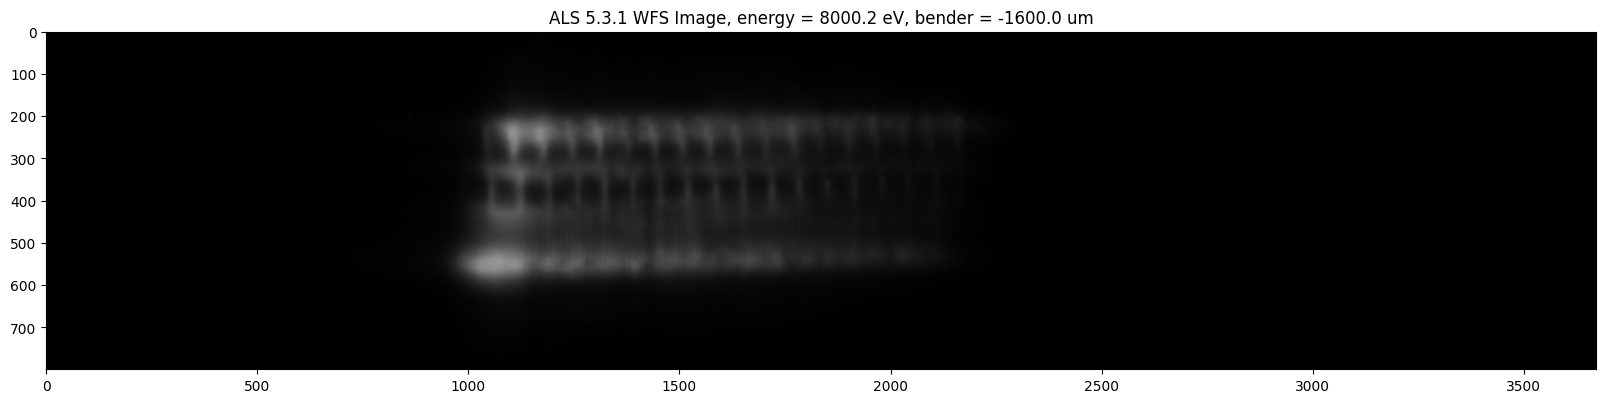

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

idx = 24
plt.figure(figsize=(20, 8))
plt.imshow(images[idx].T, cmap='gray')
plt.title('ALS 5.3.1 WFS Image, energy = {:1.1f} eV, bender = {:1.1f} um'.format(energy_eV[idx], bender_um[idx]))
plt.show()

## Analyze data
The stack of images at 8keV starts at idx=22 

code borrowed from `20260327khc_wfs_scan.ipynb`

In [9]:
import numpy as np

wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
exp_time_s = db.metadata['start']['exposure time [s]']
pixel_size_um = db.metadata['start']['pixel size [um]']
binning = db.metadata['start']['binning']
effective_pixel_size_um = db.metadata['start']['effective pixel size [um]']
camera_model = db.metadata['start']['camera model']
objective_model = db.metadata['start']['objective model']

#metadata = db.metadata['start']
#metadata_keys = list(metadata.keys())


#other useful metadata:
grating_pitch_m = 7e-6  # 
chip_ccd_distance = 300e-3



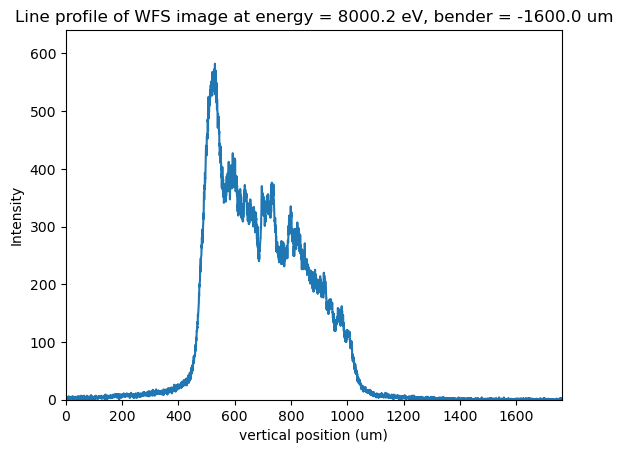

In [ ]:
x_m = (np.arange(images[idx].shape[0])) * effective_pixel_size_um *1e-6
line_profile = images[idx][:,495]
plt.plot(x_m*1e6, line_profile)
plt.xlabel('vertical position (um)')
plt.ylabel('Intensity')
plt.title('Line profile of WFS image at energy = {:1.1f} eV, bender = {:1.1f} um'.format(energy_eV[idx], bender_um[idx]))
plt.xlim(0, x_m[-1]*1e6)
plt.ylim(0, line_profile.max()*1.1)
plt.show()


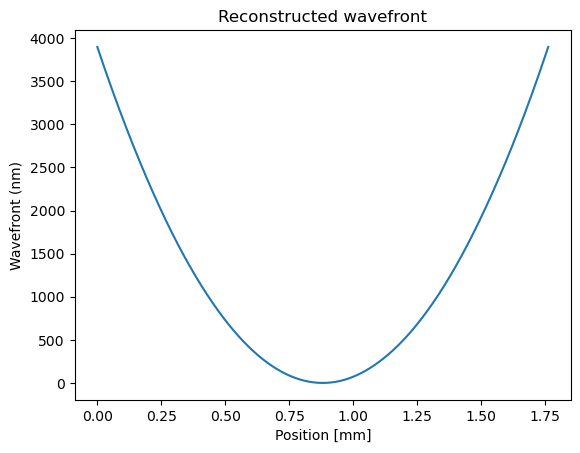

In [70]:
#other useful metadata:
grating_pitch_m = 7e-6  # 
chip_ccd_distance = 300e-3


grating_freq_cpm = 1/grating_pitch_m  # cycles per micron for 7 um pitch
wavelength_m = 1.24e-6 / (energy_eV[idx])  # Convert eV to wavelength in meters
px_m = effective_pixel_size_um * 1e-6  # Convert effective pixel size to meters

line = line_profile
line_FFT = np.fft.fftshift(np.fft.fft(line, axis=0), axes=0)
freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(line.shape[0], px_m))
I_fft = line_FFT

# Create frequency array
freq = freq_y_cpm
M = len(freq)
df = freq[1]-freq[0]  # Frequency resolution [1/m]

mask = (freq > 0.12e6) & (freq < 0.17e6)

# Find peaks in FFT spectrum (use magnitude)
I_fft_magnitude = np.abs(I_fft)
# peaks, properties = find_peaks(I_fft_magnitude*mask, height=np.max(I_fft_magnitude*mask)*0.1)

# Identify carrier frequency (should be at ±1/pitch)
carrier_freq_ideal = grating_freq_cpm
#carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - carrier_freq_ideal))]
carrier_idx = np.argmax(I_fft_magnitude*mask)
carrier_freq_measured = freq[carrier_idx]


# Create Gaussian filter centered on +1 order
filter_width = 10.0  # pixels (standard deviation)
x_indices = np.arange(M)
gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

# Apply filter to FFT
I_fft_filtered = I_fft * gaussian_filter

# Normalize for visualization (so all curves are visible on same plot)
I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

# Inverse FFT to get complex field
complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

# Extract amplitude and wrapped phase
amplitude = np.abs(complex_field)
phase_wrapped = np.angle(complex_field)

# Standard unwrap (left-to-right) and center at x=0
phase_unwrapped = np.unwrap(phase_wrapped)
phase_centered = phase_unwrapped - phase_unwrapped[M//2]

dy_m = x_m[1] - x_m[0]  # Spatial sampling interval [m]

# Simple cumulative integration with scaling
wavefront_m = np.cumsum(phase_centered) * dy_m / grating_pitch_m * wavelength_m / 2

# Re-center at x=0 to remove piston term
wavefront_reconstructed = wavefront_m - wavefront_m[M//2]
wavefront_wave = wavefront_reconstructed # Convert to meters


plt.plot(x_m*1e3, wavefront_reconstructed*1e9)
plt.title('Reconstructed wavefront')
plt.xlabel('Position [mm]')
plt.ylabel('Wavefront (nm)')
plt.show()

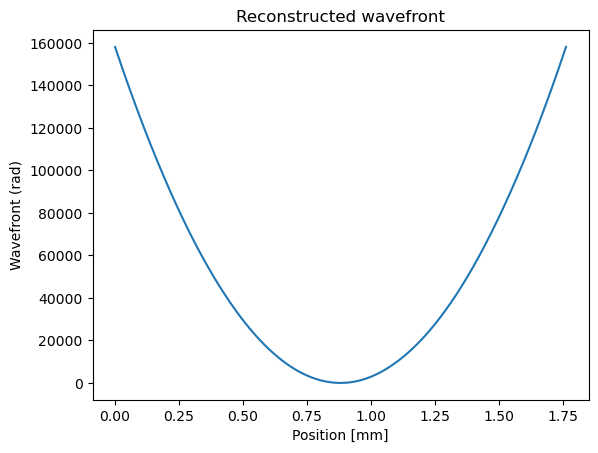

In [71]:
# Simple cumulative integration with scaling
wavefront_m = np.cumsum(phase_centered) * dy_m / grating_pitch_m * wavelength_m / 2

# Re-center at x=0 to remove piston term
wavefront_reconstructed = wavefront_m - wavefront_m[M//2]
wavefront_rad = wavefront_reconstructed/wavelength_m * 2 * np.pi # Convert to radians


plt.plot(x_m*1e3, wavefront_rad)
plt.title('Reconstructed wavefront')
plt.xlabel('Position [mm]')
plt.ylabel('Wavefront (rad)')
plt.show()

In [75]:
def estimate_wavefront(line_profile):
    #other useful metadata:
    grating_pitch_m = 7e-6  # 
    chip_ccd_distance = 300e-3


    grating_freq_cpm = 1/grating_pitch_m  # cycles per micron for 7 um pitch
    wavelength_m = 1.24e-6 / (energy_eV[idx])  # Convert eV to wavelength in meters
    px_m = effective_pixel_size_um * 1e-6  # Convert effective pixel size to meters

    line = line_profile
    line_FFT = np.fft.fftshift(np.fft.fft(line, axis=0), axes=0)
    freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(line.shape[0], px_m))
    I_fft = line_FFT

    # Create frequency array
    freq = freq_y_cpm
    M = len(freq)
    df = freq[1]-freq[0]  # Frequency resolution [1/m]

    mask = (freq > 0.12e6) & (freq < 0.17e6)

    # Find peaks in FFT spectrum (use magnitude)
    I_fft_magnitude = np.abs(I_fft)
    # peaks, properties = find_peaks(I_fft_magnitude*mask, height=np.max(I_fft_magnitude*mask)*0.1)

    # Identify carrier frequency (should be at ±1/pitch)
    carrier_freq_ideal = grating_freq_cpm
    #carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - carrier_freq_ideal))]
    carrier_idx = np.argmax(I_fft_magnitude*mask)
    carrier_freq_measured = freq[carrier_idx]


    # Create Gaussian filter centered on +1 order
    filter_width = 10.0  # pixels (standard deviation)
    x_indices = np.arange(M)
    gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

    # Apply filter to FFT
    I_fft_filtered = I_fft * gaussian_filter

    # Normalize for visualization (so all curves are visible on same plot)
    I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
    I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

    # Inverse FFT to get complex field
    complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

    # Extract amplitude and wrapped phase
    amplitude = np.abs(complex_field)
    phase_wrapped = np.angle(complex_field)

    # Standard unwrap (left-to-right) and center at x=0
    phase_unwrapped = np.unwrap(phase_wrapped)
    phase_centered = phase_unwrapped - phase_unwrapped[M//2]

    dy_m = x_m[1] - x_m[0]  # Spatial sampling interval [m]

    # Simple cumulative integration with scaling
    wavefront_m = np.cumsum(phase_centered) * dy_m / grating_pitch_m * wavelength_m / 2

    # Re-center at x=0 to remove piston term
    wavefront_reconstructed = wavefront_m - wavefront_m[M//2]
    wavefront_wave = wavefront_reconstructed # Convert to meters

    return wavefront_wave



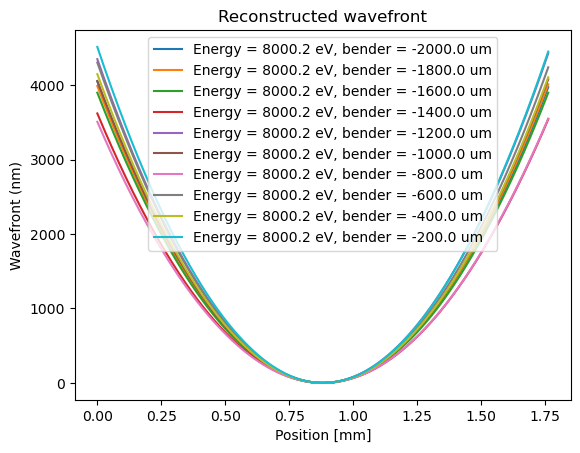

In [76]:
for idx in range(22,32):
    line_profile = images[idx][:,495]
    wavefront = estimate_wavefront(line_profile)
    plt.plot(x_m*1e3, wavefront*1e9, label='Energy = {:1.1f} eV, bender = {:1.1f} um'.format(energy_eV[idx], bender_um[idx]))
plt.title('Reconstructed wavefront')
plt.xlabel('Position [mm]')
plt.ylabel('Wavefront (nm)')
plt.legend()
plt.show()

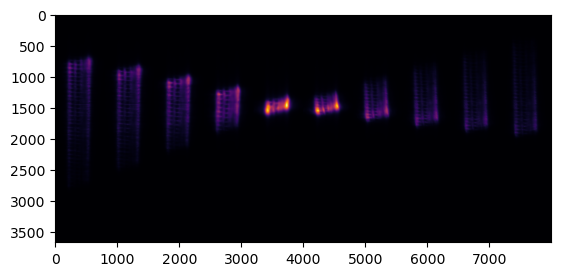

In [79]:
img_list = []
for index in range(22,32):
    img_list.append(images[index])

# Stack the images horizontally
stacked_image = np.hstack(img_list)
plt.imshow(stacked_image, cmap='inferno')
plt.show()

